In [1]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score


In [2]:

normalizado = pd.read_csv("..\\datasets_paralelos\\spotify_normalizado.csv", encoding='utf-8', low_memory=True)

In [3]:
CLUSTER_FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'valence',
    'tempo',
    'liveness',
    'instrumentalness',
]


x = normalizado[CLUSTER_FEATURES]


In [4]:
qtd = len(CLUSTER_FEATURES)
nome = f'silhueta_padronizado{qtd}features'

In [5]:
escolhido = x

For n_clusters = 12 The average silhouette_score is : 0.164022693987372
For n_clusters = 13 The average silhouette_score is : 0.17170409757431324
For n_clusters = 14 The average silhouette_score is : 0.16786872545574608


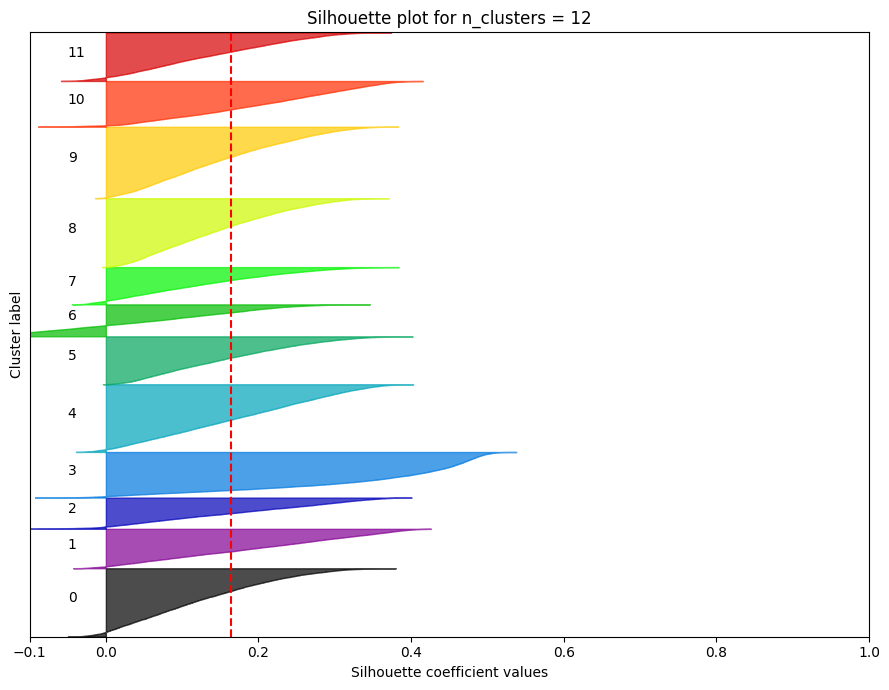

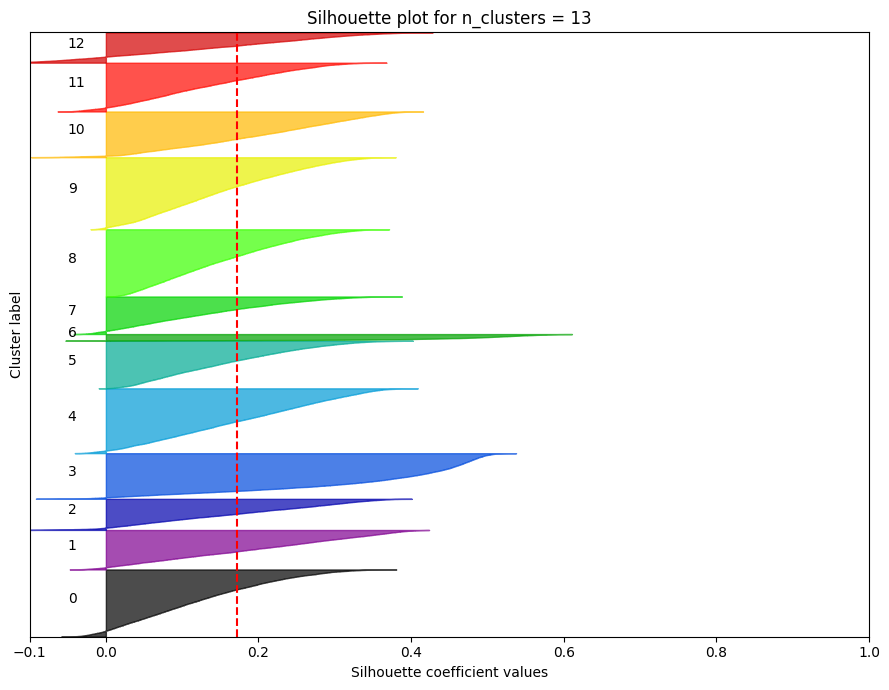

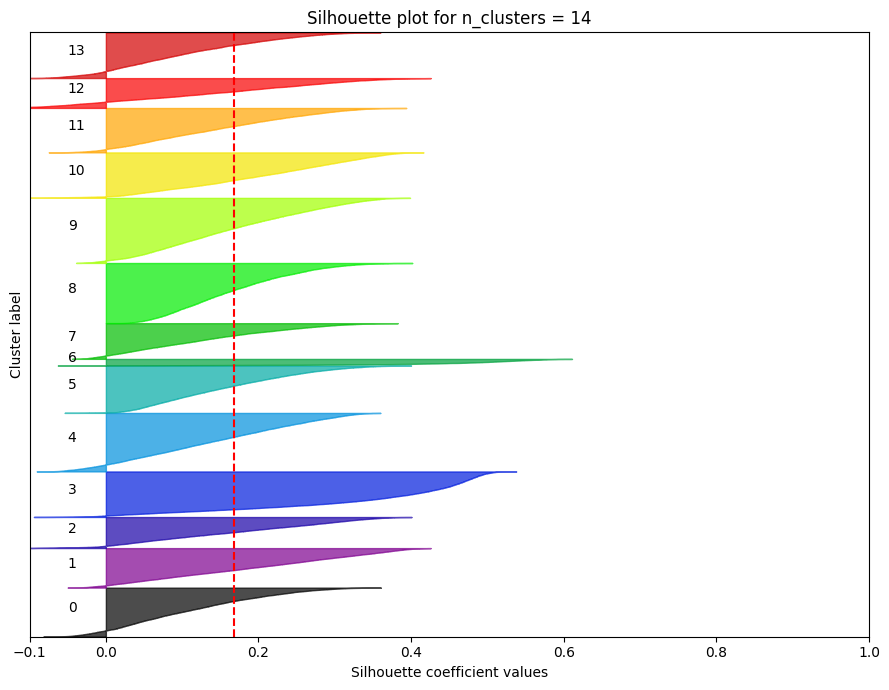

In [6]:
range_n_clusters = [12,13,14]

for n_clusters in range_n_clusters:
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(9, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(escolhido) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(escolhido)

    silhouette_avg = silhouette_score(escolhido, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    sample_silhouette_values = silhouette_samples(escolhido, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title(f"Silhouette plot for n_clusters = {n_clusters}")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.tight_layout()
    plt.savefig(f"..\\clustering_outputs\\silhouette_{n_clusters}.png", dpi=300, bbox_inches='tight')

plt.show()